In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt




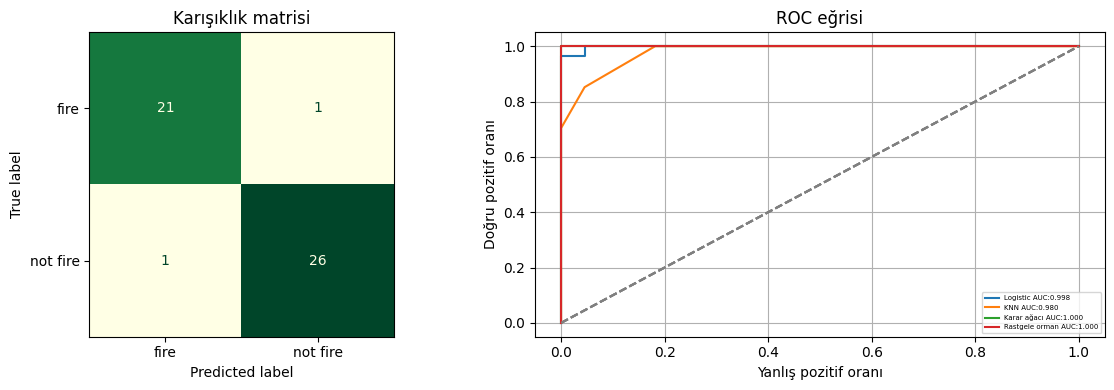

In [19]:
df = pd.read_csv("/content/algerian3.csv")

df['Classes'] = df['Classes'].str.strip()

df['Target'] = df['Classes'].map({'fire': 1, 'not fire': 0})

features = ['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI']
X = df[features]
y = df['Target']

X = X.apply(pd.to_numeric, errors='coerce')
X = X.dropna()
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

siniflandiricilar = {
    "Baseline": DummyClassifier(strategy="most_frequent").fit(X_train_scaled, y_train),
    "Logistic": LogisticRegression(max_iter=1000).fit(X_train_scaled, y_train),
    "KNN": KNeighborsClassifier().fit(X_train_scaled, y_train),
    "Karar ağacı": DecisionTreeClassifier().fit(X_train_scaled, y_train),
    "Rastgele orman": RandomForestClassifier().fit(X_train_scaled, y_train)
}

satirlar =[]

for ad,m in siniflandiricilar.items():
  m.fit(X_train,y_train)
  satirlar.append(
      {
          "Model": ad,
          "Eğitim" : accuracy_score(y_train,m.predict(X_train)),
          "Test": accuracy_score(y_test,m.predict(X_test))
      }
  )

pd.DataFrame(satirlar).set_index("Model").round(3)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

fig, axes = plt.subplots(1,2,figsize=(12,4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels =["fire","not fire"], cmap="YlGn",ax=axes[0],colorbar=False)
axes[0].set_title("Karışıklık matrisi")
axes[0].grid(False)

for ad in ["Logistic","KNN","Karar ağacı","Rastgele orman"]:
  p=siniflandiricilar[ad].predict_proba(X_test)[:,1]
  fpr,tpr,_=roc_curve(y_test,p)
  axes[1].plot(fpr,tpr,label=f"{ad} AUC:{roc_auc_score(y_test,p):.3f}")
  axes[1].plot([0,1],[0,1],linestyle="--",color="gray")
  axes[1].set_xlabel("Yanlış pozitif oranı")
  axes[1].set_ylabel("Doğru pozitif oranı")
  axes[1].set_title("ROC eğrisi")
  axes[1].legend(fontsize=5)
  axes[1].grid(True)

plt.tight_layout()
plt.show()
